<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/IMS_2ndtest_RtF_Detection_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMS 2nd_test — Run-to-Failure 조기탐지 v2
**트랙:** `onsite_r2f_ims/` (독립 노트북 — Paderborn/binary 트랙과 혼용 금지)

**목적:** 같은 베어링의 "정상 초기 등록 → 열화 이탈 조기탐지" 컨셉 검증

| 항목 | 값 |
|:---|:---|
| 파일명 형식 | `2004.02.12.10.32.39` (타임스탬프 = 시간축) |
| 파일 구조 | 20,480행 × 4열, 탭 구분, 헤더 없음 |
| 샘플링 | 20,480 Hz (파일당 1초 스냅샷) |
| 채널 매핑 | 열0=Bearing1, 열1=Bearing2, 열2=Bearing3, 열3=Bearing4 |
| 탐지 타깃 | **Bearing1 외륜(Outer race) 고장** |

**실행 순서: A(폰트) → 런타임재시작 → 폰트적용 → 1 → 2 → 3 → 4 → 5 → B → C**

In [13]:
# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회만. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
print('설치 완료 → 상단 메뉴: 런타임 > 런타임 다시 시작 (또는 Ctrl+M .)')

설치 완료 → 상단 메뉴: 런타임 > 런타임 다시 시작 (또는 Ctrl+M .)


In [14]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지
print('한글 폰트 적용 완료 (NanumGothic)')

한글 폰트 적용 완료 (NanumGothic)


In [17]:
# ============================================================
# 셀 1 — 라이브러리 & 드라이브 마운트 & 경로 확인
# ============================================================
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/IMS_NASA'

print('=== IMS_NASA 내부 폴더 구조 ===')
for root, dirs, files_in in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 1:
        break

print()
print('[확인] 출력에서 2nd_test 위치를 확인하세요.')
print('  BASE/2nd_test 이면 셀2 그대로 실행')
print('  BASE/2nd_test/2nd_test 처럼 한 겹 더 있으면 셀2의 TEST2_DIR 수정')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== IMS_NASA 내부 폴더 구조 ===
IMS_NASA/
  3rd_test/

[확인] 출력에서 2nd_test 위치를 확인하세요.
  BASE/2nd_test 이면 셀2 그대로 실행
  BASE/2nd_test/2nd_test 처럼 한 겹 더 있으면 셀2의 TEST2_DIR 수정


In [18]:
# ============================================================
# 셀 2 — 파라미터 설정 & 파일 목록 로딩 & 구조 검증
# ============================================================

# ================= 사용자 설정 =================
TEST2_DIR          = BASE + '/2nd_test'   # ← 셀1 출력 보고 필요시 수정
FS                 = 20480                # 샘플링레이트 (IMS 공식)
TARGET_BEARING_COL = 0                    # Bearing1 = 열0 (외륜 고장 타깃)
BASELINE_RATIO     = 0.15                 # 초기 15%를 정상 베이스라인으로 등록
# ==============================================

files = sorted(glob.glob(os.path.join(TEST2_DIR, '*')))
files = [f for f in files
         if re.match(r'.*\d{4}\.\d{2}\.\d{2}', os.path.basename(f))]

print(f'총 파일 수 : {len(files)}  (예상 984)')
print(f'첫  파일   : {os.path.basename(files[0])}')
print(f'마지막 파일: {os.path.basename(files[-1])}')

sample = np.loadtxt(files[0])
print(f'파일 shape : {sample.shape}  (예상 (20480, 4))')

assert len(files) > 0,           '파일을 찾을 수 없음 — TEST2_DIR 경로 확인'
assert sample.shape[0] == 20480, f'행 수 불일치: {sample.shape[0]} (예상 20480)'
assert sample.shape[1] == 4,     f'열 수 불일치: {sample.shape[1]} (예상 4)'

print()
print('✅ 파일 수·shape 정상 — 셀3으로 진행하세요')

총 파일 수 : 984  (예상 984)
첫  파일   : 2004.02.12.10.32.39
마지막 파일: 2004.02.19.06.22.39
파일 shape : (20480, 4)  (예상 (20480, 4))

✅ 파일 수·shape 정상 — 셀3으로 진행하세요


In [19]:
# ============================================================
# 셀 3 — 물리 특징 추출 전 구간 (~수 분 소요)
# ============================================================

def extract_features(sig, fs=FS):
    """1초 진동 신호(20480점) → 물리 특징 벡터 9개."""
    x = sig.astype(np.float64)

    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)

    # 포락선(envelope) 에너지 — 베어링 결함 임팩트에 민감
    env     = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))

    # 고주파 에너지 비율 (>2kHz) — 초기 결함 신호 포착
    fft_mag   = np.abs(np.fft.rfft(x))
    freqs     = np.fft.rfftfreq(len(x), 1/fs)
    hf_energy = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)

    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf_energy])

FEATURE_NAMES = ['RMS', 'Peak', 'Crest', 'Kurtosis', 'Skew',
                 'P2P', 'Std', 'EnvRMS', 'HF_ratio']

print(f'Bearing1(열{TARGET_BEARING_COL}) 특징 추출 시작 — {len(files)}개 파일...')
feats = []
for i, f in enumerate(files):
    data = np.loadtxt(f)
    sig  = data[:, TARGET_BEARING_COL]
    feats.append(extract_features(sig))
    if i % 100 == 0:
        print(f'  {i}/{len(files)} 완료...')

feats = np.array(feats)
print()
print(f'✅ 특징 행렬 shape: {feats.shape}  (파일수 × 9)')

Bearing1(열0) 특징 추출 시작 — 984개 파일...
  0/984 완료...
  100/984 완료...
  200/984 완료...
  300/984 완료...
  400/984 완료...
  500/984 완료...
  600/984 완료...
  700/984 완료...
  800/984 완료...
  900/984 완료...

✅ 특징 행렬 shape: (984, 9)  (파일수 × 9)


In [20]:
# ============================================================
# 셀 4 — 베이스라인 등록 & Mahalanobis 이탈 탐지
# ============================================================

n_base   = int(len(feats) * BASELINE_RATIO)
baseline = feats[:n_base]
print(f'베이스라인 등록: 초기 {n_base}개 파일 (전체의 {BASELINE_RATIO*100:.0f}%)')

# 정규화 기준 — 베이스라인에서만 산출 (미래 정보 누수 방지)
mu      = baseline.mean(axis=0)
sigma   = baseline.std(axis=0) + 1e-12
base_n  = (baseline - mu) / sigma
feats_n = (feats    - mu) / sigma

# Mahalanobis 거리 (베이스라인 공분산 기준)
cov_inv  = pinv(np.cov(base_n.T))
mean_vec = base_n.mean(axis=0)

def mahalanobis(v):
    d = v - mean_vec
    return np.sqrt(d @ cov_inv @ d.T)

md = np.array([mahalanobis(v) for v in feats_n])

# 임계값: mean + 3×std (기본)
base_md   = md[:n_base]
threshold = base_md.mean() + 3 * base_md.std()
print(f'이탈 임계값 (mean+3std): {threshold:.3f}')

# 연속 5개 초과 = 진짜 열화 시작
alarm_idx = None
for i in range(n_base, len(md) - 5):
    if np.all(md[i:i+5] > threshold):
        alarm_idx = i
        break

print()
if alarm_idx is not None:
    lead = len(md) - alarm_idx
    print(f'[조기탐지 성공] 파일 #{alarm_idx} — {os.path.basename(files[alarm_idx])}')
    print(f'  수명 소진율 : {alarm_idx/len(md)*100:.1f}%')
    print(f'  리드타임    : {lead}개 파일 (≈{lead*10}분, 근사)')
else:
    print('[경보 없음] → 셀 B 튜닝 표로 임계 조정하세요')

베이스라인 등록: 초기 147개 파일 (전체의 15%)
이탈 임계값 (mean+3std): 6.348

[조기탐지 성공] 파일 #532 — 2004.02.16.03.12.39
  수명 소진율 : 54.1%
  리드타임    : 452개 파일 (≈4520분, 근사)


/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/3226514265.py:38: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

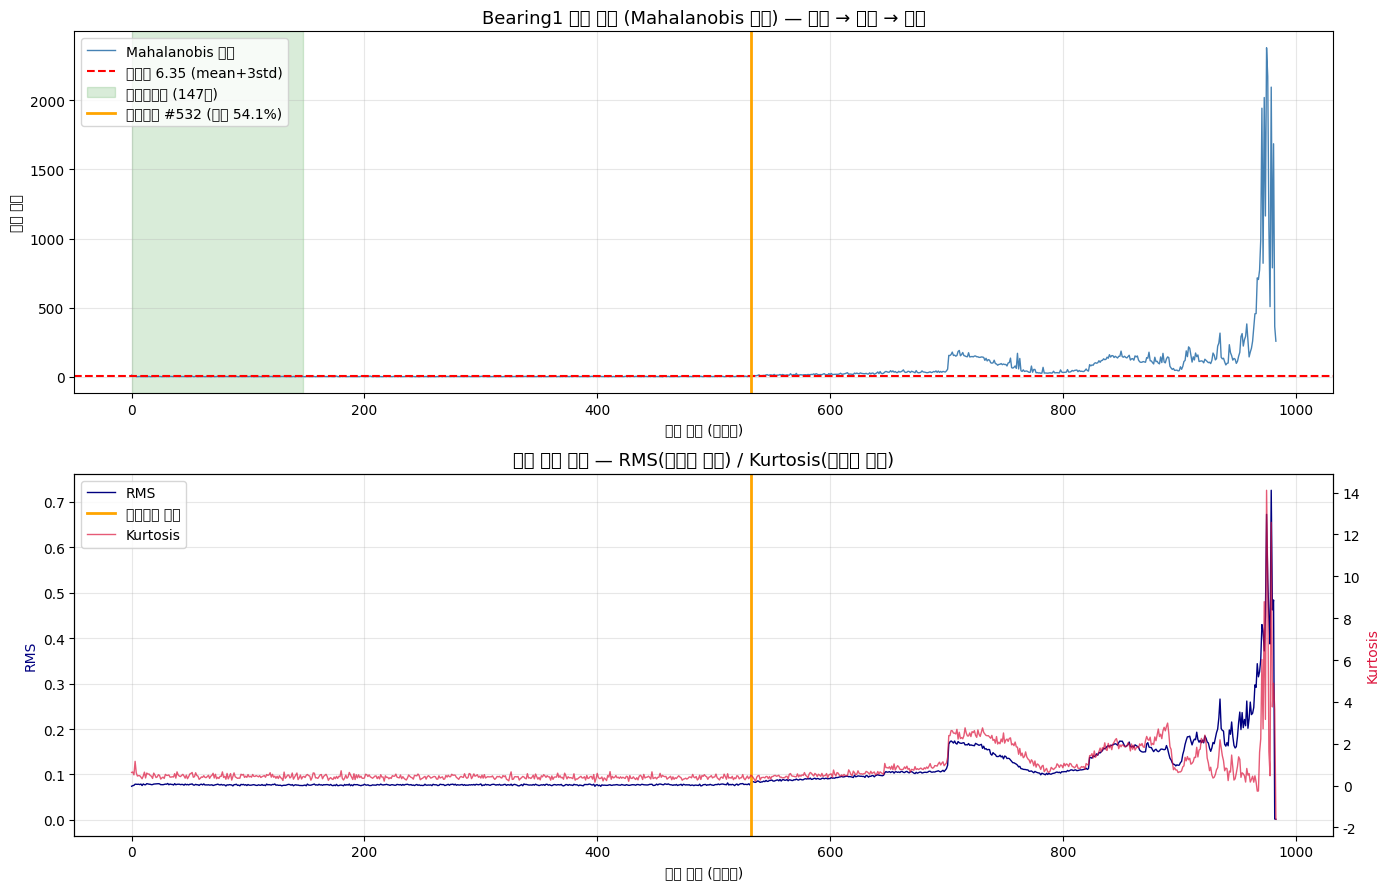

저장 완료: /content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/ims_2ndtest_result.png

  판정 요약
  경보 시점  : 파일 #532 / 전체 984개
  수명 소진율: 54.1%
  리드타임   : 452개 파일 (≈4520분, 근사)
  판정       : ⚠️  오탐 가능성 — 곡선 모양 확인 후 셀B 튜닝

[다음] 셀B — 임계배수(K) × 연속조건 튜닝 표 실행


In [21]:
# ============================================================
# 셀 5 — 시각화 & 결과 저장 & 자동 판정
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- (상) Mahalanobis 거리: 건강 상태 추이 ---
ax0 = axes[0]
ax0.plot(md, color='steelblue', lw=1, label='Mahalanobis 거리')
ax0.axhline(threshold, color='red', ls='--', lw=1.5,
            label=f'임계값 {threshold:.2f} (mean+3std)')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_idx is not None:
    ax0.axvline(alarm_idx, color='orange', lw=2,
                label=f'조기탐지 #{alarm_idx} (수명 {alarm_idx/len(md)*100:.1f}%)')
ax0.set_title('Bearing1 건강 지표 (Mahalanobis 거리) — 정상 → 열화 → 고장', fontsize=13)
ax0.set_xlabel('파일 순번 (시간축)')
ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left')
ax0.grid(alpha=0.3)

# --- (하) RMS + Kurtosis 추이: 물리 교차 검증 ---
ax1  = axes[1]
ax1b = ax1.twinx()
ax1.plot(feats[:, 0],  color='navy',    lw=1,         label='RMS')
ax1b.plot(feats[:, 3], color='crimson', lw=1, alpha=0.7, label='Kurtosis')
if alarm_idx is not None:
    ax1.axvline(alarm_idx, color='orange', lw=2, label='조기탐지 시점')
ax1.set_ylabel('RMS',       color='navy')
ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번 (시간축)')
ax1.set_title('물리 특징 추이 — RMS(에너지 증가) / Kurtosis(충격성 증가)', fontsize=13)
ax1.grid(alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()

out_dir = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
os.makedirs(out_dir, exist_ok=True)
out_png = out_dir + 'ims_2ndtest_result.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_png}')

# 판정 요약
print()
print('=' * 55)
print('  판정 요약')
print('=' * 55)
if alarm_idx is not None:
    pct  = alarm_idx / len(md) * 100
    lead = len(md) - alarm_idx
    if pct < 60:
        verdict = '⚠️  오탐 가능성 — 곡선 모양 확인 후 셀B 튜닝'
    elif pct <= 90:
        verdict = '✅  컨셉 검증 성공 (적정 리드타임 확보)'
    else:
        verdict = '⚠️  리드타임 부족 — 셀B에서 임계 완화 시도'
    print(f'  경보 시점  : 파일 #{alarm_idx} / 전체 {len(md)}개')
    print(f'  수명 소진율: {pct:.1f}%')
    print(f'  리드타임   : {lead}개 파일 (≈{lead*10}분, 근사)')
    print(f'  판정       : {verdict}')
else:
    print('  판정: ❌ 경보 없음 — 셀B 튜닝 표로 임계/연속조건 조정')
print('=' * 55)
print()
print('[다음] 셀B — 임계배수(K) × 연속조건 튜닝 표 실행')

In [9]:
# ============================================================
# 셀 B — 임계/연속조건 스윕 튜닝 표 + 추천 조합 자동 선정
# 전제: 셀3~4의 md, n_base, files 변수가 메모리에 있어야 함
# ============================================================

# ================== 튜닝 파라미터 후보 ==================
K_LIST             = [3, 4, 6, 8, 10]   # 임계 = base_mean + K×base_std
CONSEC_LIST        = [5, 10, 15]         # 연속 초과 개수 (지속성 요구)
FILE_INTERVAL_MIN  = 10                  # 파일 간 대략 간격(분) — 근사치
# ※ IMS 파일 간격은 비균일(초기 촘촘·후기 넓어짐).
#   리드타임(분)은 상대 비교용. 정밀값은 셀D(타임스탬프 보정)에서 산출.
# ======================================================

N = len(md)

def find_alarm(threshold, consec):
    for i in range(n_base, N - consec):
        if np.all(md[i:i+consec] > threshold):
            return i
    return None

def false_alarms(threshold, consec):
    """베이스라인 구간(정상 확정)에서 임계 초과 발생 횟수 = 오경보 건수"""
    fa = 0
    for i in range(0, n_base - consec):
        if np.all(md[i:i+consec] > threshold):
            fa += 1
    return fa

rows = []
for k in K_LIST:
    thr = base_md.mean() + k * base_md.std()
    for c in CONSEC_LIST:
        idx = find_alarm(thr, c)
        fa  = false_alarms(thr, c)
        if idx is not None:
            life_pct   = idx / N * 100
            lead_files = N - idx
            lead_min   = lead_files * FILE_INTERVAL_MIN
            rows.append({
                'K(임계배수)': k, '연속조건': c, '임계값': round(thr, 2),
                '경보시점(파일#)': idx,
                '수명소진율(%)': round(life_pct, 1),
                '리드타임(파일)': lead_files,
                '리드타임(분,근사)': lead_min,
                '오경보(건)': fa
            })
        else:
            rows.append({
                'K(임계배수)': k, '연속조건': c, '임계값': round(thr, 2),
                '경보시점(파일#)': None, '수명소진율(%)': None,
                '리드타임(파일)': None, '리드타임(분,근사)': None,
                '오경보(건)': fa
            })

df = pd.DataFrame(rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 120)
print('=== 임계/연속조건 튜닝 표 ===')
print(df.to_string(index=False))

# 추천 조합: 오경보 0건 & 수명소진율 55~85% & 리드타임 최대
valid = df[
    (df['오경보(건)'] == 0) &
    (df['수명소진율(%)'].notna()) &
    (df['수명소진율(%)'].between(55, 85))
]
print()
if len(valid) > 0:
    best = valid.sort_values('리드타임(파일)', ascending=False).iloc[0]
    print('=== [추천 조합] ===')
    print(f"  K={best['K(임계배수)']}, 연속={best['연속조건']}")
    print(f"  → 경보 파일 #{best['경보시점(파일#)']}")
    print(f"  → 수명 {best['수명소진율(%)']}% 시점에 경보")
    print(f"  → 오경보 {best['오경보(건)']}건")
    print(f"  → 리드타임 {best['리드타임(파일)']}개 파일 (≈{best['리드타임(분,근사)']}분, 근사)")
    print()
    print(f"  [다음] 셀C의 BEST_K={best['K(임계배수)']}, BEST_C={best['연속조건']} 로 설정 후 실행")
else:
    print('[추천 조합 없음] 55~85% & 오경보 0건 조건 불충족')
    print('  → K_LIST / CONSEC_LIST 후보를 확장하거나 기준 범위를 조정하세요')

=== 임계/연속조건 튜닝 표 ===
 K(임계배수)  연속조건   임계값  경보시점(파일#)  수명소진율(%)  리드타임(파일)  리드타임(분,근사)  오경보(건)
       3     5  6.35        532      54.1       452        4520       0
       3    10  6.35        532      54.1       452        4520       0
       3    15  6.35        532      54.1       452        4520       0
       4     5  7.55        533      54.2       451        4510       0
       4    10  7.55        533      54.2       451        4510       0
       4    15  7.55        533      54.2       451        4510       0
       6     5  9.96        543      55.2       441        4410       0
       6    10  9.96        543      55.2       441        4410       0
       6    15  9.96        543      55.2       441        4410       0
       8     5 12.37        555      56.4       429        4290       0
       8    10 12.37        566      57.5       418        4180       0
       8    15 12.37        566      57.5       418        4180       0
      10     5 14.77        581      59.0  

/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1458/1854611008.py:26: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

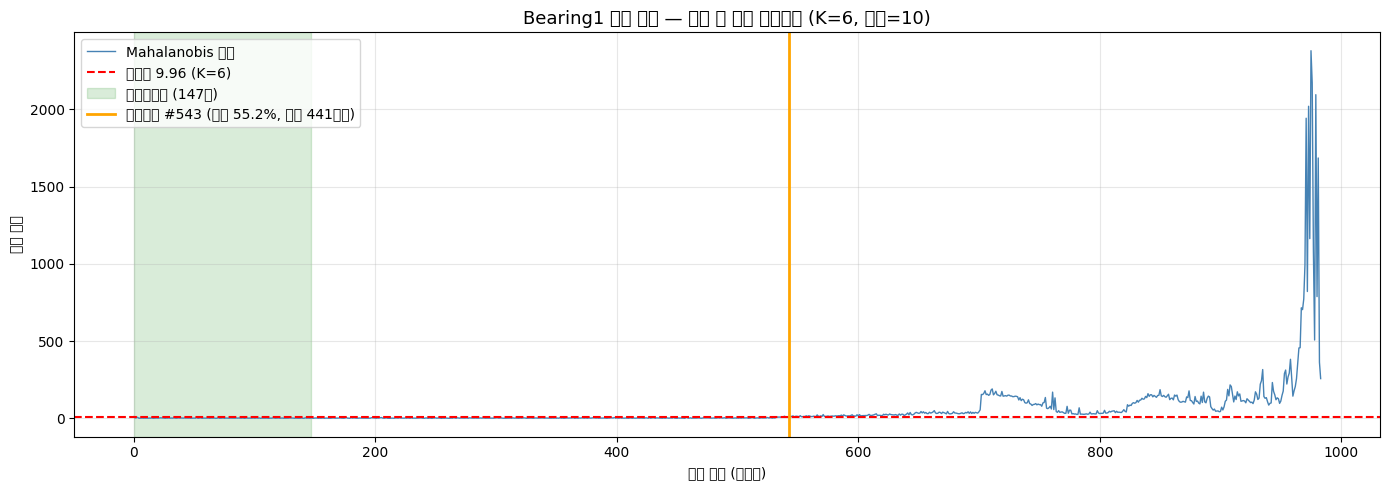

저장 완료: /content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/ims_2ndtest_tuned.png

=== 최종 KPI 요약 ===
  K=6, 연속=10
  임계값          : 9.959
  경보 시점       : 파일 #543 / 전체 984개
  수명 소진율     : 55.2%
  리드타임(근사)  : 441개 파일 ≈ 4410분
  오경보(베이스)  : 0건

  ※ 리드타임 정밀값은 셀D(타임스탬프 보정)에서 산출 가능


In [10]:
# ============================================================
# 셀 C — 추천 조합으로 최종 재시각화 & 저장
# 셀B의 [추천 조합] 출력 보고 BEST_K, BEST_C 수정 후 실행
# ============================================================

BEST_K = 6    # ← 셀B 추천값으로 수정
BEST_C = 10   # ← 셀B 추천값으로 수정

thr_best   = base_md.mean() + BEST_K * base_md.std()
alarm_best = find_alarm(thr_best, BEST_C)

plt.figure(figsize=(14, 5))
plt.plot(md, color='steelblue', lw=1, label='Mahalanobis 거리')
plt.axhline(thr_best, color='red', ls='--', lw=1.5,
            label=f'임계값 {thr_best:.2f} (K={BEST_K})')
plt.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_best is not None:
    lead_b = len(md) - alarm_best
    plt.axvline(alarm_best, color='orange', lw=2,
                label=f'조기경보 #{alarm_best} (수명 {alarm_best/len(md)*100:.1f}%, 리드 {lead_b}파일)')
plt.title(f'Bearing1 건강 지표 — 튜닝 후 실용 조기경보 (K={BEST_K}, 연속={BEST_C})', fontsize=13)
plt.xlabel('파일 순번 (시간축)')
plt.ylabel('이탈 거리')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

out_dir  = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
out_tuned = out_dir + 'ims_2ndtest_tuned.png'
plt.savefig(out_tuned, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_tuned}')

print()
print('=== 최종 KPI 요약 ===')
if alarm_best is not None:
    lead_b = len(md) - alarm_best
    fa_b   = false_alarms(thr_best, BEST_C)
    print(f'  K={BEST_K}, 연속={BEST_C}')
    print(f'  임계값          : {thr_best:.3f}')
    print(f'  경보 시점       : 파일 #{alarm_best} / 전체 {len(md)}개')
    print(f'  수명 소진율     : {alarm_best/len(md)*100:.1f}%')
    print(f'  리드타임(근사)  : {lead_b}개 파일 ≈ {lead_b*10}분')
    print(f'  오경보(베이스)  : {fa_b}건')
    print()
    print('  ※ 리드타임 정밀값은 셀D(타임스탬프 보정)에서 산출 가능')
else:
    print('  경보 없음 — BEST_K / BEST_C 재조정 필요')

In [11]:
# ============================================================
# 셀 D — 타임스탬프 기반 정밀 리드타임 산출 (선택)
# KPI 문서·보고서에 분 단위 정밀값이 필요할 때 실행
# ============================================================
from datetime import datetime

def parse_ts(fname):
    """파일명 '2004.02.12.10.32.39' → datetime 객체"""
    base = os.path.basename(fname)
    # 점 6개 = 연.월.일.시.분.초
    parts = base.split('.')
    if len(parts) >= 6:
        try:
            return datetime(int(parts[0]), int(parts[1]), int(parts[2]),
                            int(parts[3]), int(parts[4]), int(parts[5]))
        except Exception:
            pass
    return None

timestamps = [parse_ts(f) for f in files]
valid_ts   = [(i, t) for i, t in enumerate(timestamps) if t is not None]

if len(valid_ts) < 2:
    print('타임스탬프 파싱 실패 — 파일명 형식 확인 필요')
else:
    t_start = valid_ts[0][1]
    t_end   = valid_ts[-1][1]
    total_min = (t_end - t_start).total_seconds() / 60
    print(f'실험 시작: {t_start}')
    print(f'실험 종료: {t_end}')
    print(f'총 실험 시간: {total_min:.1f}분 ({total_min/60:.1f}시간)')

    # 경보 시점 기준 (셀C의 alarm_best 사용)
    target_alarm = alarm_best if 'alarm_best' in dir() else alarm_idx
    if target_alarm is not None and timestamps[target_alarm] is not None:
        t_alarm    = timestamps[target_alarm]
        lead_exact = (t_end - t_alarm).total_seconds() / 60
        print()
        print(f'경보 시점: {t_alarm}')
        print(f'정밀 리드타임: {lead_exact:.1f}분 ({lead_exact/60:.2f}시간)')
        print(f'수명 소진율  : {(t_alarm - t_start).total_seconds() / (t_end - t_start).total_seconds() * 100:.1f}%')
    else:
        print('경보 시점 없음 또는 타임스탬프 없음')

실험 시작: 2004-02-12 10:32:39
실험 종료: 2004-02-19 06:22:39
총 실험 시간: 9830.0분 (163.8시간)

경보 시점: 2004-02-16 05:02:39
정밀 리드타임: 4400.0분 (73.33시간)
수명 소진율  : 55.2%


## 결과 판정 가이드

| 경보 시점(수명%) | 판정 | 조치 |
|:---:|:---:|:---|
| 60~90% | ✅ 성공 | 그대로 확정. RMS·Kurtosis 후반 상승도 교차 확인 |
| 90% 초과 | ⚠️ 늦은 경보 | K를 낮추거나 연속조건 완화 |
| 60% 미만 | ⚠️ 이른 경보 | 오탐 곡선 확인. BASELINE_RATIO=0.20 시도 |
| 경보 없음 | ❌ | TARGET_BEARING_COL 0→1→2→3 순서로 교체 시도 |

## 튜닝 파라미터 위치

```python
# 셀2
BASELINE_RATIO     = 0.15   # 조정 범위: 0.10~0.20
TARGET_BEARING_COL = 0      # Bearing1=0, 2=1, 3=2, 4=3

# 셀B
K_LIST      = [3, 4, 6, 8, 10]   # 확장 가능
CONSEC_LIST = [5, 10, 15]         # 확장 가능

# 셀C
BEST_K = 6    # 셀B 추천값
BEST_C = 10   # 셀B 추천값
```

## 다음 단계 로드맵
1. ✅ 성공 시 → `CLAUDE.md` onsite_r2f_ims 섹션에 KPI 수치 기록
2. 보너스 → IMS 3rd_test(Bearing3 외륜) 동일 코드로 일반화 확인
3. 이후 → STM32N6 엣지 이식: Mahalanobis + 물리특징 고정소수점 변환 (IIS3DWB 대역 맞춤)